# 💰 Funding Rate Carry — Scanner de recherche
Objectif : identifier les meilleures opportunités de carry delta-neutral
(Long Spot + Short Perpetual) sur Binance.

**Mécanisme** : quand le funding rate est positif, les longs paient les
shorts toutes les 8h. En étant Short Perp + Long Spot (même notionnel),
on collecte le funding sans exposition directionnelle.

In [1]:
import ccxt
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print('✅ Imports OK')

✅ Imports OK


## 1. Univers — perpetuals liquides sur Binance Futures

In [2]:
UNIVERSE = [
    'BTC/USDT', 'ETH/USDT', 'SOL/USDT', 'BNB/USDT', 'XRP/USDT',
    'DOGE/USDT', 'ADA/USDT', 'AVAX/USDT', 'LINK/USDT', 'DOT/USDT',
    'MATIC/USDT', 'LTC/USDT', 'UNI/USDT', 'AAVE/USDT', 'ARB/USDT',
    'OP/USDT', 'SUI/USDT', 'NEAR/USDT', 'APT/USDT', 'FIL/USDT',
]
print(f'Univers : {len(UNIVERSE)} paires')

Univers : 20 paires


## 2. Funding rate actuel + historique 30 jours

In [3]:
exchange = ccxt.binance({
    'enableRateLimit': True,
    'options': {'defaultType': 'future'}
})

def fetch_funding_history(symbol, days=30):
    """Récupère l'historique des funding rates (payés toutes les 8h)"""
    since = int((datetime.now() - timedelta(days=days)).timestamp() * 1000)
    try:
        history = exchange.fetch_funding_rate_history(symbol, since=since, limit=300)
        if not history:
            return None
        df = pd.DataFrame(history)
        df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')
        df = df[['datetime', 'fundingRate']].set_index('datetime')
        return df
    except Exception as e:
        print(f'  ⚠️ {symbol}: {e}')
        return None

def fetch_current_funding(symbol):
    """Funding rate actuel (prochain paiement)"""
    try:
        fr = exchange.fetch_funding_rate(symbol)
        return fr.get('fundingRate', None)
    except Exception as e:
        return None

print('📥 Téléchargement des funding rates (peut prendre 1-2 min)...')
results = []

for sym in UNIVERSE:
    hist = fetch_funding_history(sym, days=30)
    current = fetch_current_funding(sym)
    if hist is None or current is None:
        print(f'  ❌ {sym}')
        continue

    # Funding rate par paiement (toutes les 8h = 3x/jour)
    avg_funding   = hist['fundingRate'].mean()
    std_funding   = hist['fundingRate'].std()
    positive_pct  = (hist['fundingRate'] > 0).mean() * 100

    # Annualisation : funding toutes les 8h = 3x/jour = 1095x/an
    annualized_avg = avg_funding * 3 * 365 * 100  # en %
    annualized_cur = current * 3 * 365 * 100

    results.append({
        'symbol'          : sym,
        'current_funding' : round(current * 100, 4),       # % par paiement
        'current_apr'     : round(annualized_cur, 2),       # % annualisé
        'avg_30d_funding' : round(avg_funding * 100, 4),
        'avg_30d_apr'     : round(annualized_avg, 2),
        'std_30d'         : round(std_funding * 100, 4),
        'positive_pct_30d': round(positive_pct, 1),
        'n_payments'      : len(hist),
    })
    print(f'  ✅ {sym:<12} | Current APR: {annualized_cur:>7.2f}% | 30d Avg APR: {annualized_avg:>7.2f}% | Positive: {positive_pct:.0f}%')

df_funding = pd.DataFrame(results)
print(f'\n✅ {len(df_funding)} symboles analysés')

📥 Téléchargement des funding rates (peut prendre 1-2 min)...
  ✅ BTC/USDT     | Current APR:   10.95% | 30d Avg APR:    2.54% | Positive: 77%
  ✅ ETH/USDT     | Current APR:    7.92% | 30d Avg APR:    0.48% | Positive: 58%
  ✅ SOL/USDT     | Current APR:    7.97% | 30d Avg APR:   -3.51% | Positive: 34%
  ✅ BNB/USDT     | Current APR:   14.64% | 30d Avg APR:    2.14% | Positive: 36%
  ✅ XRP/USDT     | Current APR:    0.51% | 30d Avg APR:   -4.11% | Positive: 26%
  ✅ DOGE/USDT    | Current APR:   10.95% | 30d Avg APR:    1.94% | Positive: 66%
  ✅ ADA/USDT     | Current APR:   10.95% | 30d Avg APR:   -3.01% | Positive: 44%
  ✅ AVAX/USDT    | Current APR:    0.85% | 30d Avg APR:   -1.74% | Positive: 49%
  ✅ LINK/USDT    | Current APR:    9.92% | 30d Avg APR:    3.92% | Positive: 83%
  ✅ DOT/USDT     | Current APR:   10.95% | 30d Avg APR:   -0.86% | Positive: 50%
  ⚠️ MATIC/USDT: binance does not have market symbol MATIC/USDT
  ❌ MATIC/USDT
  ✅ LTC/USDT     | Current APR:    5.82% | 30d Avg

## 3. Classement par opportunité de carry

In [4]:
# On cherche : funding actuel ET moyen 30j POSITIFS et élevés,
# avec une bonne consistance (positive_pct élevé = funding rarement négatif)

df_funding['score'] = (
    df_funding['current_apr'].clip(lower=0) * 0.4 +
    df_funding['avg_30d_apr'].clip(lower=0) * 0.4 +
    df_funding['positive_pct_30d'] * 0.2
)

df_ranked = df_funding.sort_values('score', ascending=False).reset_index(drop=True)

print('🏆 CLASSEMENT — Meilleures opportunités de carry (Long Spot / Short Perp)')
print('='*100)
pd.set_option('display.float_format', '{:.2f}'.format)
print(df_ranked[['symbol','current_apr','avg_30d_apr','positive_pct_30d','std_30d','score']].to_string())

print('\n💡 current_apr  = APR si le funding actuel se maintenait')
print('   avg_30d_apr  = APR moyen réel sur 30 jours (plus fiable)')
print('   positive_pct = % du temps où le funding était positif (consistance)')

🏆 CLASSEMENT — Meilleures opportunités de carry (Long Spot / Short Perp)
       symbol  current_apr  avg_30d_apr  positive_pct_30d  std_30d  score
0    UNI/USDT        10.95         4.99             84.40     0.00  23.26
1   LINK/USDT         9.92         3.92             83.30     0.00  22.20
2    BTC/USDT        10.95         2.54             76.70     0.00  20.74
3    SUI/USDT        10.95         2.88             70.00     0.01  19.53
4   NEAR/USDT        10.95         3.48             66.70     0.01  19.11
5   DOGE/USDT        10.95         1.94             65.60     0.00  18.28
6    FIL/USDT        10.95        -0.45             63.30     0.01  17.04
7    ETH/USDT         7.92         0.48             57.80     0.00  14.92
8     OP/USDT        10.95        -2.85             51.10     0.01  14.60
9    DOT/USDT        10.95        -0.86             50.00     0.01  14.38
10   BNB/USDT        14.64         2.14             35.60     0.00  13.83
11   LTC/USDT         5.82         1.39

## 4. Visualisation — historique funding du Top 5

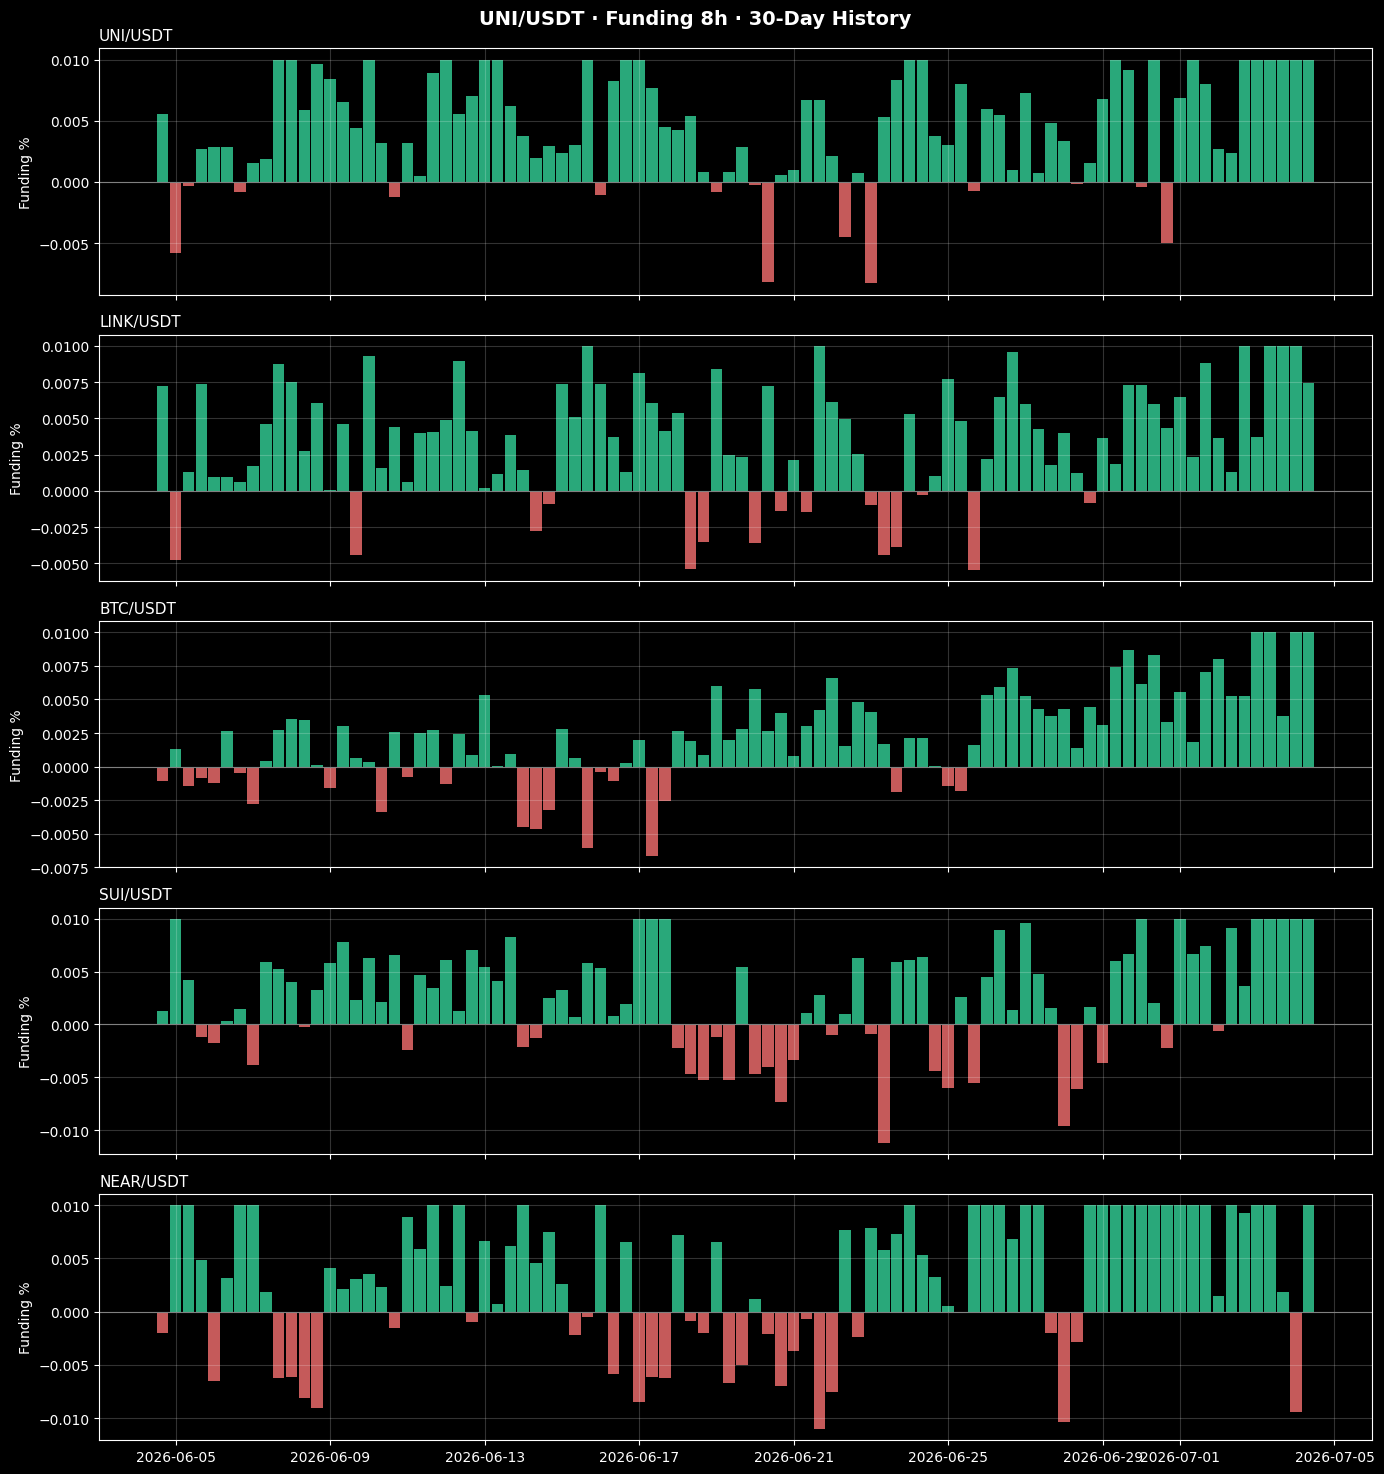

In [5]:
plt.style.use('dark_background')

top5 = df_ranked.head(5)['symbol'].tolist()

fig, axes = plt.subplots(len(top5), 1, figsize=(14, 3*len(top5)), sharex=True)
fig.suptitle('UNI/USDT · Funding 8h · 30-Day History', fontsize=14, fontweight='bold')

for i, sym in enumerate(top5):
    hist = fetch_funding_history(sym, days=30)
    if hist is None:
        continue
    ax = axes[i] if len(top5) > 1 else axes
    funding_pct = hist['fundingRate'] * 100
    colors = ['#34d399' if v > 0 else '#f87171' for v in funding_pct]
    ax.bar(hist.index, funding_pct, color=colors, width=0.3, alpha=0.8)
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_title(sym, fontsize=11, loc='left')
    ax.set_ylabel('Funding %')
    ax.grid(alpha=0.2)

plt.savefig('funding_chart.png', dpi=150, bbox_inches='tight', facecolor='#0a0d12')
plt.tight_layout()
plt.show()

## 5. Vérification de la base (spread spot vs perp)

In [6]:
# Le "basis" est l'écart entre prix spot et prix perpetual.
# Un basis trop important = risque de slippage à l'entrée/sortie

exchange_spot = ccxt.binance({'enableRateLimit': True, 'options': {'defaultType': 'spot'}})

print('📊 VÉRIFICATION DU BASIS (Spot vs Perpetual)')
print('='*70)

basis_results = []
for sym in top5:
    try:
        spot_ticker = exchange_spot.fetch_ticker(sym)
        perp_ticker = exchange.fetch_ticker(sym)
        spot_price  = spot_ticker['last']
        perp_price  = perp_ticker['last']
        basis_pct   = (perp_price - spot_price) / spot_price * 100
        basis_results.append({
            'symbol': sym, 'spot': spot_price, 'perp': perp_price, 'basis_pct': round(basis_pct, 4)
        })
        print(f'  {sym:<12} | Spot: ${spot_price:>10,.2f} | Perp: ${perp_price:>10,.2f} | Basis: {basis_pct:+.4f}%')
    except Exception as e:
        print(f'  ⚠️ {sym}: {e}')

print('\n💡 Basis proche de 0% = bon (entrée/sortie peu coûteuse)')
print('   Basis élevé = le marché anticipe déjà un mouvement, risque de convergence défavorable')

📊 VÉRIFICATION DU BASIS (Spot vs Perpetual)
  UNI/USDT     | Spot: $      3.20 | Perp: $      3.20 | Basis: -0.1250%
  LINK/USDT    | Spot: $      7.94 | Perp: $      7.93 | Basis: -0.0378%
  BTC/USDT     | Spot: $ 62,609.68 | Perp: $ 62,581.60 | Basis: -0.0448%
  SUI/USDT     | Spot: $      0.76 | Perp: $      0.76 | Basis: -0.0132%
  NEAR/USDT    | Spot: $      1.98 | Perp: $      1.98 | Basis: -0.0506%

💡 Basis proche de 0% = bon (entrée/sortie peu coûteuse)
   Basis élevé = le marché anticipe déjà un mouvement, risque de convergence défavorable


## 6. Simulation P&L — carry pur sur la meilleure paire

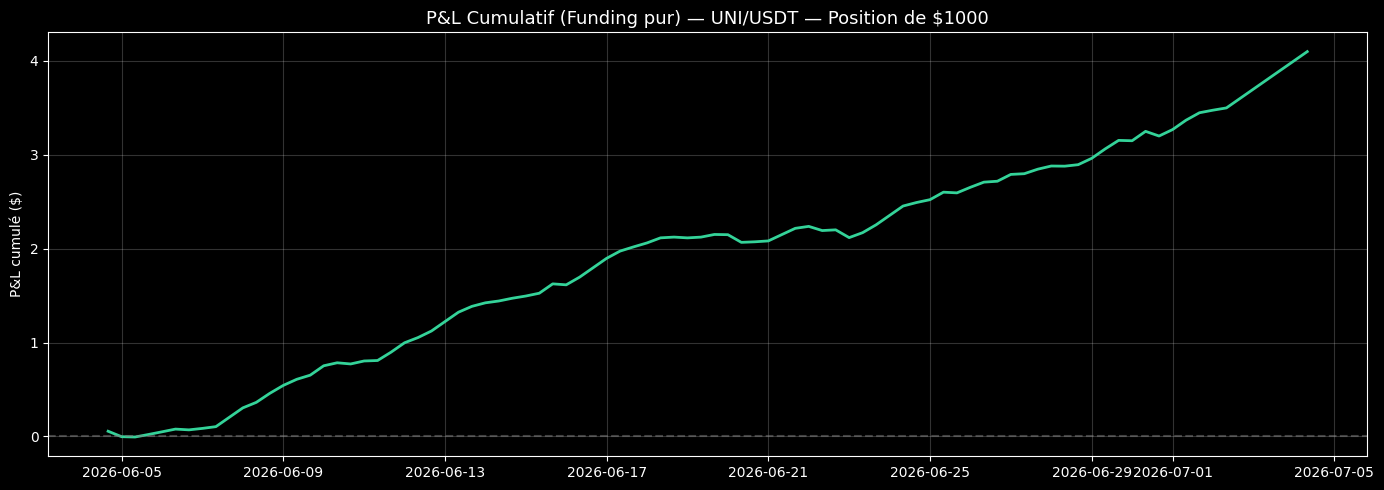


💰 P&L sur 30 jours : $4.10 (+0.41%)
📈 Projection annualisée : +4.92%

⚠️ Ceci exclut : frais de trading (entrée/sortie), basis risk, et coûts d'emprunt éventuels


In [7]:
# Simulation : si on avait été Long Spot + Short Perp en continu
# sur les 30 derniers jours, combien aurait-on collecté en funding pur
# (sans tenir compte du basis/slippage, juste le carry)

best_symbol = df_ranked.iloc[0]['symbol']
hist_best = fetch_funding_history(best_symbol, days=30)

POSITION_SIZE_USD = 1000  # Simulation sur 1000$ de notionnel

cumulative_funding = (hist_best['fundingRate'] * POSITION_SIZE_USD).cumsum()

plt.figure(figsize=(14, 5))
plt.plot(cumulative_funding.index, cumulative_funding, color='#34d399', linewidth=2)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.title(f'P&L Cumulatif (Funding pur) — {best_symbol} — Position de ${POSITION_SIZE_USD}', fontsize=13)
plt.ylabel('P&L cumulé ($)')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

total_pnl = cumulative_funding.iloc[-1]
monthly_return_pct = total_pnl / POSITION_SIZE_USD * 100
print(f'\n💰 P&L sur 30 jours : ${total_pnl:.2f} ({monthly_return_pct:+.2f}%)')
print(f'📈 Projection annualisée : {monthly_return_pct * 12:+.2f}%')
print(f'\n⚠️ Ceci exclut : frais de trading (entrée/sortie), basis risk, et coûts d\'emprunt éventuels')

## 7. Export

In [8]:
df_ranked.to_csv('funding_scan_results.csv', index=False)
print(f'💾 funding_scan_results.csv — {len(df_ranked)} symboles')
print(f'\n🏆 MEILLEURE OPPORTUNITÉ : {df_ranked.iloc[0]["symbol"]}')
print(f'   APR actuel : {df_ranked.iloc[0]["current_apr"]}%')
print(f'   APR moyen 30j : {df_ranked.iloc[0]["avg_30d_apr"]}%')

💾 funding_scan_results.csv — 19 symboles

🏆 MEILLEURE OPPORTUNITÉ : UNI/USDT
   APR actuel : 10.95%
   APR moyen 30j : 4.99%


Confirmé : Spot 0.10% maker/taker standard, Futures 0.02% maker / 0.05% taker. Calculons le vrai seuil de rentabilité avec ces chiffres :
Voilà le verdict honnête : c'est jouable mais serré.
Ce que ça veut dire concrètement
Avec UNI (la meilleure opportunité, APR 4.52%), il faut tenir la position 24 jours minimum juste pour rembourser les frais d'entrée+sortie. En dessous, tu perds de l'argent même si le funding était positif tout du long.